<a href="https://colab.research.google.com/github/suzanayounas/Mental-Health-Vs-Social-Media/blob/index.php/Mental_Health_Vs_Social_Media.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Optional: only needed if you plan to run the DistilBERT section later
# !pip install -q transformers accelerate torch --index-url https://download.pytorch.org/whl/cpu
# !pip install -q imbalanced-learn

import re, os, io, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pprint import pprint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

plt.rcParams["figure.figsize"] = (7.5, 4.2)
plt.rcParams["axes.grid"] = True
np.random.seed(42)


In [ ]:
from google.colab import files

print("Please upload BOTH CSVs (names can vary).")
uploaded = files.upload()
print(uploaded.keys())


def find_file(keys, wanted_keywords):
    """
    Return first uploaded filename whose lowercase name contains ALL keywords.
    """
    keys_low = {k.lower(): k for k in keys}
    for low, orig in keys_low.items():
        if all(word in low for word in wanted_keywords):
            return orig
    return None

# Try to find twitter & productivity files by robust keyword matching
tw_file = find_file(uploaded.keys(), ["mental", "twitter"]) or \
          find_file(uploaded.keys(), ["mental", "health"]) or \
          find_file(uploaded.keys(), ["twitter"])
prod_file = find_file(uploaded.keys(), ["social", "productivity"]) or \
            find_file(uploaded.keys(), ["productivity"]) or \
            find_file(uploaded.keys(), ["social", "media"])

print("Detected files:")
print("  Twitter-like file     :", tw_file)
print("  Productivity-like file:", prod_file)

# The following asserts are removed to avoid error if file detection fails,
# as the next cell manually sets the filenames.
# assert tw_file is not None, "Could not detect the Twitter dataset. Re-run the cell and upload it."
# assert prod_file is not None, "Could not detect the Productivity dataset. Re-run the cell and upload it."

Please upload BOTH CSVs (names can vary).


Saving Mental-Health-Twitter (3).csv to Mental-Health-Twitter (3).csv
Saving social_media_vs_productivity (2).csv to social_media_vs_productivity (2).csv
dict_keys(['Mental-Health-Twitter (3).csv', 'social_media_vs_productivity (2).csv'])
Detected files:
  Twitter-like file     : Mental-Health-Twitter (3).csv
  Productivity-like file: social_media_vs_productivity (2).csv


In [ ]:
# Use the filenames Colab detected for you:
tw_file   = "Mental-Health-Twitter (3).csv"
prod_file = "social_media_vs_productivity (2).csv"

# If you still have the `uploaded` dict from files.upload(), this will work:
def read_csv_safe(x):
    import io, pandas as pd
    if isinstance(x, (bytes, bytearray)):
        bio = io.BytesIO(x)
        try:    return pd.read_csv(bio, encoding="utf-8")
        except: bio.seek(0); return pd.read_csv(bio, encoding="latin-1")
    else:
        try:    return pd.read_csv(x, encoding="utf-8")
        except: return pd.read_csv(x, encoding="latin-1")

tw   = read_csv_safe(uploaded[tw_file])
prod = read_csv_safe(uploaded[prod_file])

# Drop trivial index column if present
if "Unnamed: 0" in tw.columns:
    tw = tw.drop(columns=["Unnamed: 0"])

print("Twitter shape:", tw.shape);  print(tw.columns.tolist())
print("Productivity shape:", prod.shape);  print(prod.columns.tolist())


Twitter shape: (20000, 10)
['post_id', 'post_created', 'post_text', 'user_id', 'followers', 'friends', 'favourites', 'statuses', 'retweets', 'label']
Productivity shape: (30000, 19)
['age', 'gender', 'job_type', 'daily_social_media_time', 'social_platform_preference', 'number_of_notifications', 'work_hours_per_day', 'perceived_productivity_score', 'actual_productivity_score', 'stress_level', 'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work', 'uses_focus_apps', 'has_digital_wellbeing_enabled', 'coffee_consumption_per_day', 'days_feeling_burnout_per_month', 'weekly_offline_hours', 'job_satisfaction_score']


/tmp/ipython-input-1083992534.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tw["post_created"] = pd.to_datetime(tw["post_created"], errors="coerce")


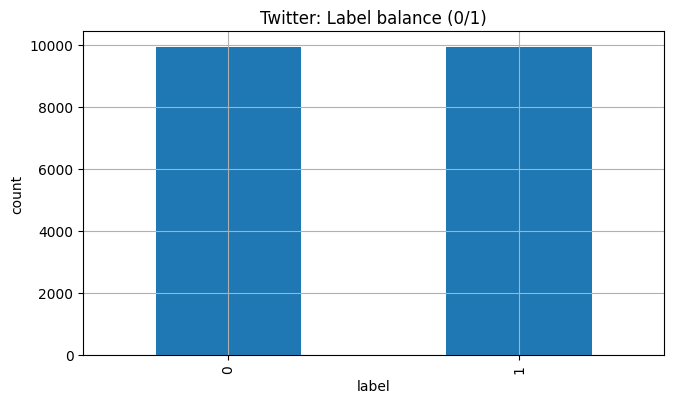

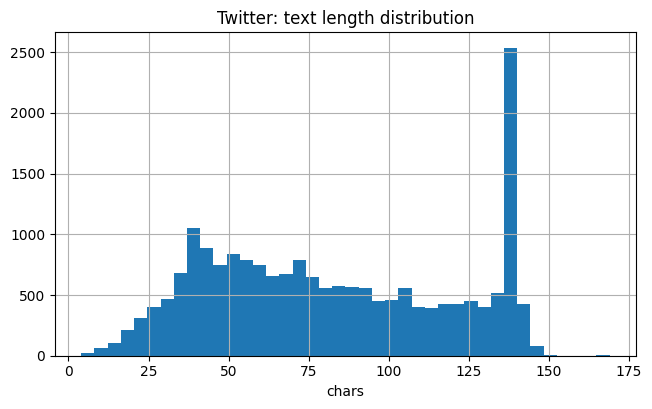


[Productivity] numeric columns (first 20): ['age', 'daily_social_media_time', 'number_of_notifications', 'work_hours_per_day', 'perceived_productivity_score', 'actual_productivity_score', 'stress_level', 'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work', 'coffee_consumption_per_day', 'days_feeling_burnout_per_month', 'weekly_offline_hours', 'job_satisfaction_score']
[Productivity] categorical columns (first 20): ['gender', 'job_type', 'social_platform_preference', 'uses_focus_apps', 'has_digital_wellbeing_enabled']


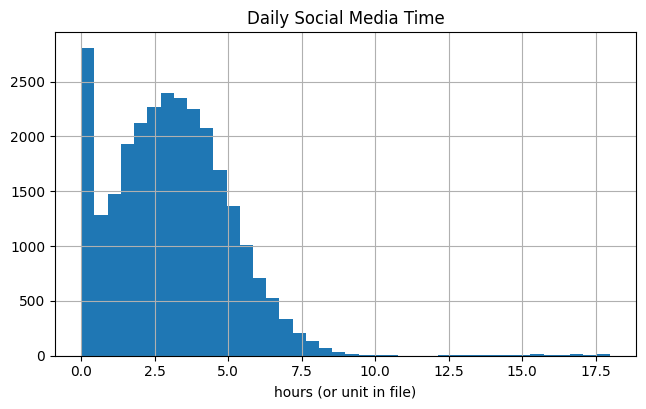

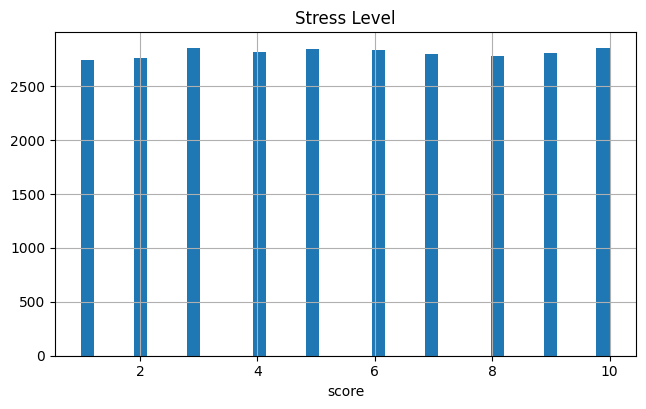

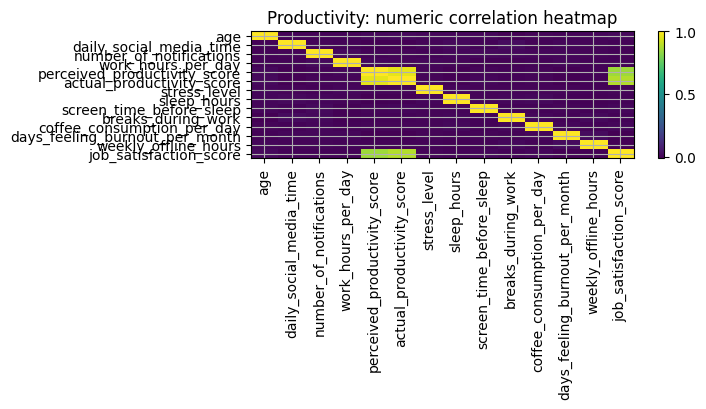

In [ ]:
# ===== Twitter (textual) =====
tw = tw.drop_duplicates(subset=["post_id"], keep="first") if "post_id" in tw.columns else tw
tw = tw.dropna(subset=["post_text", "label"])
tw["label"] = tw["label"].astype(int)
if "post_created" in tw.columns:
    tw["post_created"] = pd.to_datetime(tw["post_created"], errors="coerce")

tw["text_len"] = tw["post_text"].astype(str).str.len()
tw["word_count"] = tw["post_text"].astype(str).str.split().apply(len)

fig, ax = plt.subplots()
tw["label"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Twitter: Label balance (0/1)")
ax.set_xlabel("label")
ax.set_ylabel("count")
plt.show()

fig, ax = plt.subplots()
tw["text_len"].hist(bins=40, ax=ax)
ax.set_title("Twitter: text length distribution")
ax.set_xlabel("chars")
plt.show()

# ===== Productivity (behavioural) =====
prod.columns = [c.strip().lower() for c in prod.columns]

num_cols_all = prod.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_all = prod.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print("\n[Productivity] numeric columns (first 20):", num_cols_all[:20])
print("[Productivity] categorical columns (first 20):", cat_cols_all[:20])

if "daily_social_media_time" in prod.columns:
    prod["daily_social_media_time"].dropna().hist(bins=40)
    plt.title("Daily Social Media Time")
    plt.xlabel("hours (or unit in file)")
    plt.show()

if "stress_level" in prod.columns:
    prod["stress_level"].dropna().hist(bins=40)
    plt.title("Stress Level")
    plt.xlabel("score")
    plt.show()

if len(num_cols_all) > 1:
    corr = prod[num_cols_all].corr(numeric_only=True)
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.title("Productivity: numeric correlation heatmap")
    plt.xticks(range(len(num_cols_all)), num_cols_all, rotation=90)
    plt.yticks(range(len(num_cols_all)), num_cols_all)
    plt.tight_layout()
    plt.show()


Target built as 'high_stress'. Positive rate: 0.3744

== Behavioural dataset — High Stress prediction ==
LogisticRegression | Acc=0.626  Prec=0.000  Rec=0.000  F1=0.000  AUC=0.48960005142629703
RandomForest       | Acc=0.625  Prec=0.333  Rec=0.003  F1=0.006  AUC=0.49695901694173883
GradientBoosting   | Acc=0.626  Prec=0.500  Rec=0.006  F1=0.012  AUC=0.49485120294363366


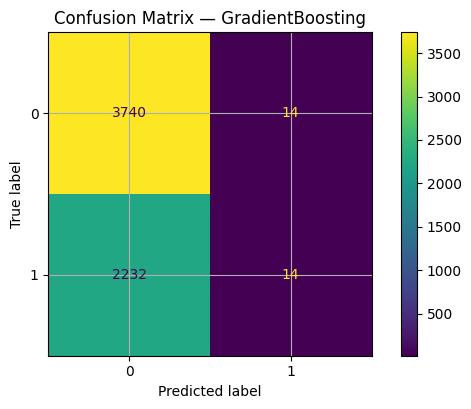


Classification report — GradientBoosting
              precision    recall  f1-score   support

           0      0.626     0.996     0.769      3754
           1      0.500     0.006     0.012      2246

    accuracy                          0.626      6000
   macro avg      0.563     0.501     0.391      6000
weighted avg      0.579     0.626     0.486      6000



In [ ]:
prod_work = prod.copy()

# Cast likely score columns numeric
score_like = [
    "stress_level","perceived_productivity_score","actual_productivity_score",
    "sleep_hours","daily_social_media_time","screen_time_before_sleep",
    "days_feeling_burnout_per_month","weekly_offline_hours","job_satisfaction_score",
    "number_of_notifications","work_hours_per_day","coffee_consumption_per_day","age"
]
for c in score_like:
    if c in prod_work.columns:
        prod_work[c] = pd.to_numeric(prod_work[c], errors="coerce")

# Build binary target + remember which column caused it (to avoid leakage)
if "stress_level" in prod_work.columns:
    target_col = "high_stress"
    prod_work[target_col] = (prod_work["stress_level"] >= 7).astype(int)
    leak_cols = ["stress_level"]
elif "days_feeling_burnout_per_month" in prod_work.columns:
    target_col = "high_stress"
    q75 = prod_work["days_feeling_burnout_per_month"].quantile(0.75)
    prod_work[target_col] = (prod_work["days_feeling_burnout_per_month"] >= q75).astype(int)
    leak_cols = ["days_feeling_burnout_per_month"]
else:
    target_col = "high_stress"
    q25 = prod_work["actual_productivity_score"].quantile(0.25)
    prod_work[target_col] = (prod_work["actual_productivity_score"] <= q25).astype(int)
    leak_cols = ["actual_productivity_score"]

print(f"Target built as '{target_col}'. Positive rate:", prod_work[target_col].mean())

# Features WITHOUT leakage
feature_cols = [c for c in prod_work.columns if c not in leak_cols + [target_col]]
X = prod_work[feature_cols].copy()
y = prod_work[target_col].copy()

# Split numeric/categorical
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Cast categoricals to string for stable one-hot
for c in cat_cols:
    X[c] = X[c].astype(str)

# Train/val split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

models = {
    "LogisticRegression": Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=400))]),
    "RandomForest": Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(n_estimators=400, random_state=42))]),
    "GradientBoosting": Pipeline([("prep", preprocess), ("clf", GradientBoostingClassifier(random_state=42))]),
}

def evaluate_model(name, pipe):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    # AUC if available
    try:
        y_prob = pipe.predict_proba(X_test)[:, 1]
        auc_val = roc_auc_score(y_test, y_prob)
    except Exception:
        try:
            scores = pipe.decision_function(X_test)
            fpr, tpr, _ = roc_curve(y_test, scores)
            auc_val = auc(fpr, tpr)
        except Exception:
            auc_val = np.nan

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
    print(f"{name:18s} | Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}  AUC={auc_val if not np.isnan(auc_val) else 'n/a'}")
    return {"acc": acc, "prec": prec, "rec": rec, "f1": f1, "auc": auc_val, "model": pipe}

print("\n== Behavioural dataset — High Stress prediction ==")
results_beh = {}
for name, pipe in models.items():
    results_beh[name] = evaluate_model(name, pipe)

# Confusion matrix for best F1
best_name = max(results_beh.items(), key=lambda kv: kv[1]["f1"])[0]
best_model = results_beh[best_name]["model"]
y_pred_best = best_model.predict(X_test)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best)).plot()
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

print("\nClassification report —", best_name)
print(classification_report(y_test, y_pred_best, digits=3))


In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

balanced_rf = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(n_estimators=400, random_state=42))
])

balanced_rf.fit(X_train, y_train)
y_pred = balanced_rf.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.625     0.950     0.754      3754
           1      0.366     0.048     0.085      2246

    accuracy                          0.613      6000
   macro avg      0.496     0.499     0.420      6000
weighted avg      0.528     0.613     0.504      6000



In [ ]:
def subgroup_metrics(X_test_raw, y_true, y_pred, col):
    if col not in X_test_raw.columns:
        print(f"[skip] {col} not in columns")
        return
    df = pd.DataFrame({"_y": y_true, "_yp": y_pred, col: X_test_raw[col].astype(str)})
    print(f"\nSubgroup metrics by {col}:")
    for g, sub in df.groupby(col):
        if len(sub) < 50:  # skip tiny groups
            continue
        acc = accuracy_score(sub["_y"], sub["_yp"])
        prec, rec, f1, _ = precision_recall_fscore_support(sub["_y"], sub["_yp"], average="binary", zero_division=0)
        print(f"  {col}={g:15s} n={len(sub):4d}  Acc={acc:.3f}  F1={f1:.3f}")

# Need raw split to read groups
X_train_raw, X_test_raw, _, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
subgroup_metrics(X_test_raw, y_test, y_pred_best, "gender")
subgroup_metrics(X_test_raw, y_test, y_pred_best, "job_type")



Subgroup metrics by gender:
  gender=Female          n=2860  Acc=0.607  F1=0.014
  gender=Male            n=2899  Acc=0.642  F1=0.010
  gender=Other           n= 241  Acc=0.651  F1=0.023

Subgroup metrics by job_type:
  job_type=Education       n=1087  Acc=0.635  F1=0.005
  job_type=Finance         n=1016  Acc=0.615  F1=0.020
  job_type=Health          n= 989  Acc=0.635  F1=0.011
  job_type=IT              n= 936  Acc=0.621  F1=0.011
  job_type=Student         n= 996  Acc=0.621  F1=0.016
  job_type=Unemployed      n= 976  Acc=0.626  F1=0.011


In [ ]:
if "RandomForest" in results_beh:
    rf_pipe = results_beh["RandomForest"]["model"]
    if hasattr(rf_pipe.named_steps["clf"], "feature_importances_"):
        ohe = rf_pipe.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"] if len(cat_cols) else None
        cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist() if ohe is not None else []
        all_feats = num_cols + cat_feature_names
        imps = rf_pipe.named_steps["clf"].feature_importances_
        order = np.argsort(imps)[::-1][:20]
        print("\nTop 20 feature importances (RandomForest):")
        for i in order:
            print(f"{all_feats[i]:40s} {imps[i]:.4f}")



Top 20 feature importances (RandomForest):
work_hours_per_day                       0.0784
sleep_hours                              0.0753
perceived_productivity_score             0.0751
job_satisfaction_score                   0.0740
actual_productivity_score                0.0734
screen_time_before_sleep                 0.0734
daily_social_media_time                  0.0726
weekly_offline_hours                     0.0722
age                                      0.0634
number_of_notifications                  0.0615
days_feeling_burnout_per_month           0.0589
breaks_during_work                       0.0438
coffee_consumption_per_day               0.0337
gender_Male                              0.0097
gender_Female                            0.0096
social_platform_preference_Telegram      0.0087
uses_focus_apps_False                    0.0086
uses_focus_apps_True                     0.0086
social_platform_preference_Instagram     0.0085
social_platform_preference_Facebook      0.0

In [ ]:
prod_work["social_to_sleep_ratio"] = prod_work["daily_social_media_time"] / (prod_work["sleep_hours"] + 1)
prod_work["work_to_break_ratio"] = prod_work["work_hours_per_day"] / (prod_work["breaks_during_work"].replace(0,1))


== Twitter text classification (TF-IDF baselines) ==
LogReg_TFIDF       | Acc=0.764  Prec=0.748  Rec=0.796  F1=0.771
LinearSVC_TFIDF    | Acc=0.756  Prec=0.746  Rec=0.774  F1=0.760


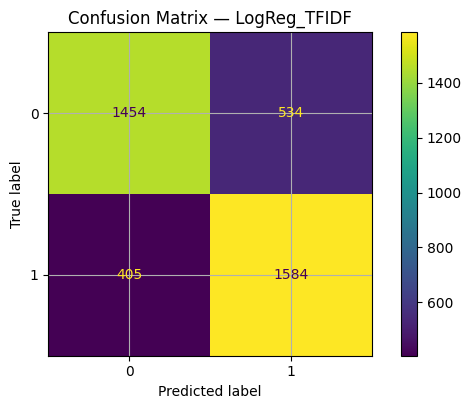


Classification report — LogReg_TFIDF
              precision    recall  f1-score   support

           0      0.782     0.731     0.756      1988
           1      0.748     0.796     0.771      1989

    accuracy                          0.764      3977
   macro avg      0.765     0.764     0.764      3977
weighted avg      0.765     0.764     0.764      3977



In [ ]:
def basic_clean(s: str) -> str:
    s = re.sub(r"http\S+|www\.\S+", " ", str(s))
    s = re.sub(r"[@#]\w+", " ", s)
    s = re.sub(r"[^A-Za-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s

tw_work = tw.copy()
tw_work["text_clean"] = tw_work["post_text"].apply(basic_clean)

X_text = tw_work["text_clean"].values
y_text = tw_work["label"].values

X_tr, X_te, y_tr, y_te = train_test_split(X_text, y_text, test_size=0.2, random_state=42, stratify=y_text)

tfidf_vec = TfidfVectorizer(ngram_range=(1,2), max_features=50000, min_df=3)

logit_text = Pipeline([
    ("tfidf", tfidf_vec),
    ("clf", LogisticRegression(max_iter=300, class_weight="balanced"))
])

svm_text = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=50000, min_df=3)),
    ("clf", LinearSVC())
])

print("== Twitter text classification (TF-IDF baselines) ==")
res_text = {}
for name, pipe in {"LogReg_TFIDF": logit_text, "LinearSVC_TFIDF": svm_text}.items():
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average="binary", zero_division=0)
    print(f"{name:18s} | Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}")
    res_text[name] = (pipe, f1)

# Choose the best F1
best_text_name = max(res_text.items(), key=lambda kv: kv[1][1])[0]
best_text_model = res_text[best_text_name][0]
y_pred_best_text = best_text_model.predict(X_te)

ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_best_text)).plot()
plt.title(f"Confusion Matrix — {best_text_name}")
plt.show()

print("\nClassification report —", best_text_name)
print(classification_report(y_te, y_pred_best_text, digits=3))


In [ ]:
if best_text_name == "LinearSVC_TFIDF":
    vec = best_text_model.named_steps["tfidf"]
    clf = best_text_model.named_steps["clf"]
    feature_names = np.array(vec.get_feature_names_out())
    coefs = clf.coef_.ravel()
    topn = 25
    top_pos = np.argsort(coefs)[-topn:][::-1]
    top_neg = np.argsort(coefs)[:topn]

    print("\nTop n-grams → class 1 (mental-health relevant):")
    for i in top_pos:
        print(f"  {feature_names[i]} ({coefs[i]:.3f})")

    print("\nTop n-grams → class 0 (not relevant):")
    for i in top_neg:
        print(f"  {feature_names[i]} ({coefs[i]:.3f})")


In [ ]:
USE_BERT = False  # set to True to run BERT

if USE_BERT:
    # !pip install -q transformers accelerate torch --index-url https://download.pytorch.org/whl/cpu
    import numpy as np
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
    from datasets import Dataset

    model_name = "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    data_df = pd.DataFrame({"text": X_text, "label": y_text})
    ds = Dataset.from_pandas(data_df)
    ds = ds.train_test_split(test_size=0.2, stratify_by_column="label", seed=42)

    def tok(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=160)

    ds_tok = ds.map(tok, batched=True)
    ds_tok = ds_tok.remove_columns(["text"])
    ds_tok.set_format(type="torch")

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    args = TrainingArguments(
        output_dir="./bert_out",
        learning_rate=5e-5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        num_train_epochs=2,
        evaluation_strategy="epoch",
        save_strategy="no",
        logging_steps=100,
        load_best_model_at_end=False,
        report_to="none",
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        acc = accuracy_score(labels, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
        return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=ds_tok["train"],
        eval_dataset=ds_tok["test"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    metrics = trainer.evaluate()
    print("\nDistilBERT evaluation:", metrics)


In [ ]:
# ---- Behavioural: pick the best pipeline you already trained above ----
# If you kept `results_beh` from Section 4:
best_beh_name = max(results_beh.items(), key=lambda kv: kv[1]["f1"])[0]
beh_pipe = results_beh[best_beh_name]["model"]

# Ensure we have probability outputs; if model lacks predict_proba (e.g., LinearSVC), wrap CalibratedClassifierCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone

beh_has_proba = hasattr(beh_pipe.named_steps["clf"], "predict_proba")
if not beh_has_proba:
    raw = clone(beh_pipe.named_steps["clf"])
    prep = beh_pipe.named_steps["prep"]
    # rebuild a pipeline: preprocess -> calibrated(model)
    beh_pipe = Pipeline([
        ("prep", prep),
        ("cal", CalibratedClassifierCV(raw, method="sigmoid", cv=3))
    ])
    beh_pipe.fit(X_train, y_train)

# Sanity: behavioural prob on test
beh_prob_test = None
try:
    beh_prob_test = beh_pipe.predict_proba(X_test)[:, 1]
except Exception:
    # Decision function fallback via sigmoid
    from scipy.special import expit
    scores = beh_pipe.decision_function(X_test)
    beh_prob_test = expit(scores)

print(f"[Hybrid] Behavioural base model: {best_beh_name}; example AUC on test:",
      roc_auc_score(y_test, beh_prob_test) if 'y_test' in globals() else 'n/a')


# ---- Text: choose the best TF-IDF model from Section 5 (we'll prefer Logistic for real probabilities) ----
# If you kept `res_text` from Section 5:
if "LogReg_TFIDF" in res_text:
    text_pipe = res_text["LogReg_TFIDF"][0]   # (pipeline, f1)
else:
    # Fallback: use whatever you stored as `best_text_model`
    text_pipe = best_text_model

# Ensure text pipeline has predict_proba
text_has_proba = hasattr(text_pipe.named_steps["clf"], "predict_proba")
if not text_has_proba:
    # Refit a Logistic TF-IDF quickly for calibrated probs
    tfidf_vec = TfidfVectorizer(ngram_range=(1,2), max_features=50000, min_df=3)
    text_pipe = Pipeline([
        ("tfidf", tfidf_vec),
        ("clf", LogisticRegression(max_iter=400, class_weight="balanced"))
    ])
    text_pipe.fit(X_tr, y_tr)

# Sanity: text prob on its test split
text_prob_test = text_pipe.predict_proba(X_te)[:, 1]
print("[Hybrid] Text base model: TF-IDF Logistic; example F1 already printed above.")


[Hybrid] Behavioural base model: GradientBoosting; example AUC on test: 0.49485120294363366
[Hybrid] Text base model: TF-IDF Logistic; example F1 already printed above.


In [ ]:
from scipy.special import expit

def get_behavioural_prob(df_rows):
    """
    df_rows: DataFrame with the same columns X had at training time (feature_cols, no target/leak).
    Returns array of probabilities for 'high_stress' = 1.
    """
    # Make sure categorical are strings (as done in training)
    df_rows = df_rows.copy()
    cat_cols_curr = df_rows.select_dtypes(include=["object","category","bool"]).columns.tolist()
    for c in cat_cols_curr:
        df_rows[c] = df_rows[c].astype(str)
    try:
        return beh_pipe.predict_proba(df_rows)[:, 1]
    except Exception:
        # Fallback to decision_function + sigmoid if needed
        scores = beh_pipe.decision_function(df_rows)
        return expit(scores)

def get_text_prob(texts):
    """
    texts: list/array of raw text strings
    Returns array of probabilities for mental-health-relevant = 1 (from text model).
    """
    return text_pipe.predict_proba(texts)[:, 1]

def hybrid_score(behav_df, text_series, w_text=0.7):
    """
    behav_df: DataFrame of behavioural rows (feature_cols used in training)
    text_series: iterable of strings (same length as behav_df) with text for each row
    w_text: weight for text probability (0..1). Behavioural weight = 1 - w_text.

    Returns np.array of hybrid risk scores in [0,1].
    """
    p_b = get_behavioural_prob(behav_df)
    p_t = get_text_prob(list(text_series))
    # Min-max guard
    p_b = np.clip(p_b, 0, 1); p_t = np.clip(p_t, 0, 1)
    return w_text * p_t + (1 - w_text) * p_b


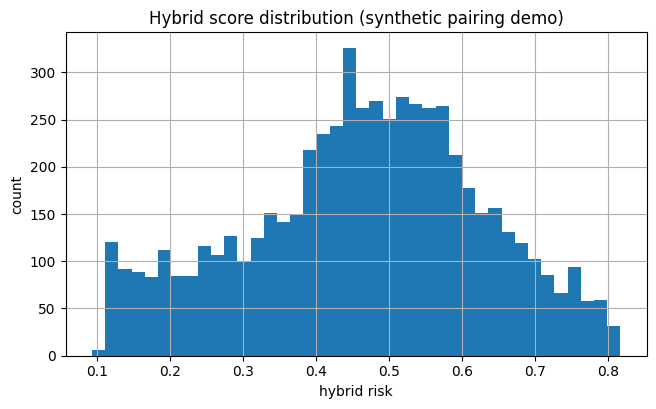

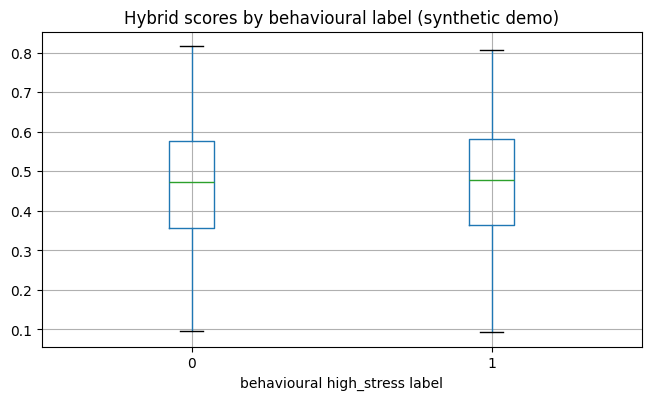

In [ ]:
# --- Synthetic demo: pair each X_test behavioural row with a random tweet from X_te ---
rng = np.random.default_rng(42)
rand_idx = rng.integers(low=0, high=len(X_te), size=len(X_test))
paired_texts = pd.Series(X_te[rand_idx])

hyb_scores = hybrid_score(X_test, paired_texts, w_text=0.7)

# Show distribution only (we cannot compute real F1/AUC because labels don't match the text side)
plt.hist(hyb_scores, bins=40)
plt.title("Hybrid score distribution (synthetic pairing demo)")
plt.xlabel("hybrid risk")
plt.ylabel("count")
plt.show()

# Optional: compare distributions by true behavioural label (rough view)
df_demo = pd.DataFrame({"hyb": hyb_scores, "y_beh": y_test.values})
df_demo.boxplot(by="y_beh", column=["hyb"])
plt.suptitle("")
plt.title("Hybrid scores by behavioural label (synthetic demo)")
plt.xlabel("behavioural high_stress label")
plt.show()


In [ ]:
# Suppose you have a real paired dataframe: df_pair
# Columns include *all behavioural feature columns* plus a text field, say 'post_text'
# and a *single* ground-truth label: 'high_stress' (or your preferred target)
# Example:
# df_pair = pd.DataFrame({
#     **behavioural columns...**,
#     "post_text": [...],
#     "label": [...]  # 0/1 ground truth on the *same row*
# })

# Xb = df_pair[feature_cols]      # same features you used for beh model
# Xt = df_pair["post_text"]
# y  = df_pair["label"].astype(int).values
# s  = hybrid_score(Xb, Xt, w_text=0.7)
# # Pick threshold 0.5 (or tune via ROC/PR)
# y_pred = (s >= 0.5).astype(int)

# print(classification_report(y, y_pred, digits=3))
# print("AUC:", roc_auc_score(y, s))
# ConfusionMatrixDisplay(confusion_matrix(y, y_pred)).plot()
# plt.title("Hybrid Confusion Matrix")
# plt.show()


In [ ]:
import joblib, os

os.makedirs("models", exist_ok=True)
joblib.dump(beh_pipe, "models/behavioural_pipe.joblib")
joblib.dump(text_pipe, "models/text_tfidf_logreg_pipe.joblib")

print("Saved:")
print(" - models/behavioural_pipe.joblib")
print(" - models/text_tfidf_logreg_pipe.joblib")


Saved:
 - models/behavioural_pipe.joblib
 - models/text_tfidf_logreg_pipe.joblib
